<a href="https://colab.research.google.com/github/parthibnandi555/Machine_learning/blob/main/lung_detection_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pydicom


In [ ]:
import os
import numpy as np
import cv2
import pydicom
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
!ls -lh

total 4.0K
drwxr-xr-x 1 root root 4.0K Mar 17 17:58 sample_data


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kabil007/lungcancer4types-imagedataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'lungcancer4types-imagedataset' dataset.
Path to dataset files: /kaggle/input/lungcancer4types-imagedataset


In [ ]:
image_folder = path + "/Data"


In [ ]:
import os
print(os.listdir(image_folder)[:10])

['valid', 'test', 'train']


In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

In [ ]:
IMG_SIZE = 128

images = []
labels = []

# FIX: Point to a specific split, like 'train'
train_folder = os.path.join(image_folder, "train")

# The classes will now be the folders inside 'train' (e.g., adenocarcinoma, normal, etc.)
classes = os.listdir(train_folder)
print("Classes found:", classes)

for label, category in enumerate(classes):
    folder_path = os.path.join(train_folder, category)

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        # Read the image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        images.append(img)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("Images loaded:", len(images))
print("Dataset shape:", X.shape)

Classes found: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib']
Images loaded: 613
Dataset shape: (613, 128, 128, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (490, 128, 128, 1)
Test shape: (123, 128, 128, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (490, 128, 128, 1)
Test shape: (123, 128, 128, 1)


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,580 (12.61 MB)

 Trainable params: 3,304,580 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 795ms/step - accuracy: 0.3469 - loss: 1.2865 - val_accuracy: 0.5610 - val_loss: 1.1087
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 698ms/step - accuracy: 0.5673 - loss: 0.9914 - val_accuracy: 0.7236 - val_loss: 0.9591
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 690ms/step - accuracy: 0.6653 - loss: 0.8248 - val_accuracy: 0.6260 - val_loss: 0.7770
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 671ms/step - accuracy: 0.7020 - loss: 0.7673 - val_accuracy: 0.8130 - val_loss: 0.6275
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 811ms/step - accuracy: 0.7694 - loss: 0.6379 - val_accuracy: 0.7805 - val_loss: 0.5581


In [ ]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)



4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.7805 - loss: 0.5581
Test Accuracy: 0.7804877758026123


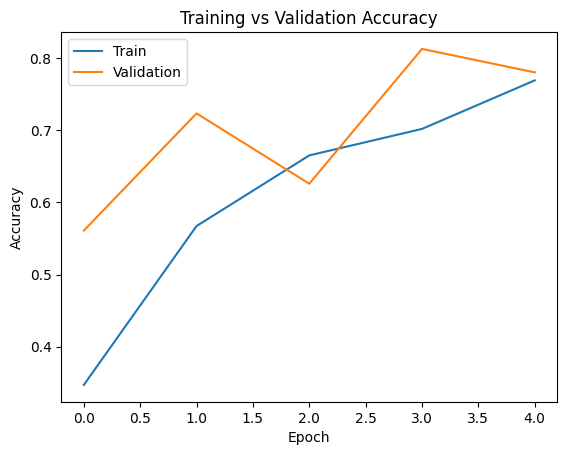

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
cm = confusion_matrix(y_test, y_pred)

print(cm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step
[[18  0  4  9]
 [ 0 29  1  0]
 [ 1  1 20  1]
 [ 2  3  5 29]]


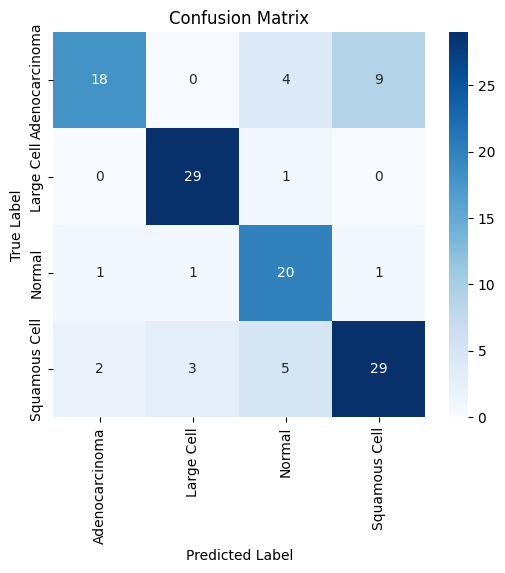

In [ ]:
class_names = [
    "Adenocarcinoma",
    "Large Cell",
    "Normal",
    "Squamous Cell"
]

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

                precision    recall  f1-score   support

Adenocarcinoma       0.86      0.58      0.69        31
    Large Cell       0.88      0.97      0.92        30
        Normal       0.67      0.87      0.75        23
 Squamous Cell       0.74      0.74      0.74        39

      accuracy                           0.78       123
     macro avg       0.79      0.79      0.78       123
  weighted avg       0.79      0.78      0.78       123

